In [1]:
#default font size:
import matplotlib.pyplot as plt
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)


In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "unsupervised_learning"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# k-Means

NOTE:
- simple algorithm capable of clustering data like blobs instances (figure shown in notebook) very quickly and efficiently
- use KMeans class from sklearn.clusters
- specify the number of clusters k that the algorithm has to find
- KMeans instance preserves the predicted labels of the instances it was trained on , available via the labels_ instance variable

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np

blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],
                         [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000,  centers=blob_centers, cluster_std=blob_std, random_state=7)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

In [4]:
y_pred

array([2, 2, 4, ..., 1, 4, 2], shape=(2000,), dtype=int32)

In [5]:
kmeans

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [6]:
y_pred is kmeans.labels_

True

In [7]:
import numpy as np
X_new = np.array([[0,2], [3,2], [4,5], [-3,3], [-3, 2.5]])
kmeans.predict(X_new)

array([0, 4, 4, 1, 1], dtype=int32)

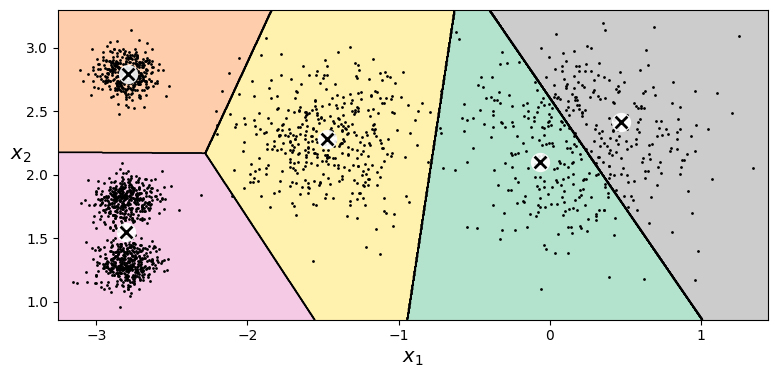

In [8]:
#plottting cluster's decision boundaries:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
save_fig("voronoi_plot")
plt.show()



In [9]:
kmeans.transform(X_new).round(2)

array([[0.12, 2.9 , 2.84, 1.5 , 0.63],
       [3.07, 5.85, 5.82, 4.48, 2.56],
       [4.99, 7.14, 7.63, 6.11, 4.38],
       [3.07, 0.29, 1.46, 1.69, 3.52],
       [2.96, 0.36, 0.97, 1.54, 3.47]])

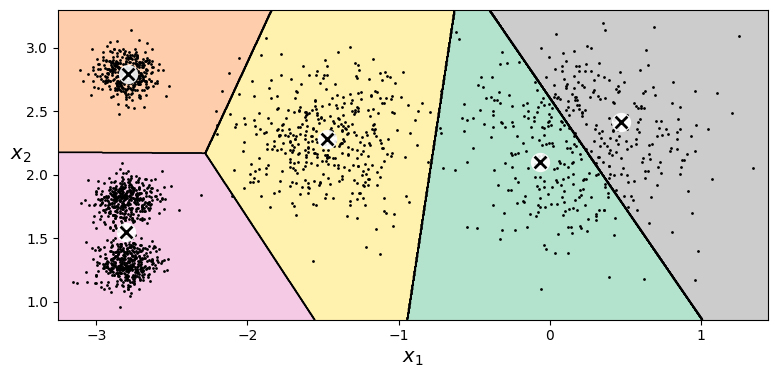

In [10]:

# extra code – this cell generates and saves Figure 9–3

def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
save_fig("voronoi_plot")
plt.show()

**k-means algorithm**

Note:
- First initialize *k* cetroids randomly then label the instances and then update centroid and repeat the process until centroid stops moving
- algorithm is guranteed to converge but may not converge at right solution (i.e. may converge at local optimum)

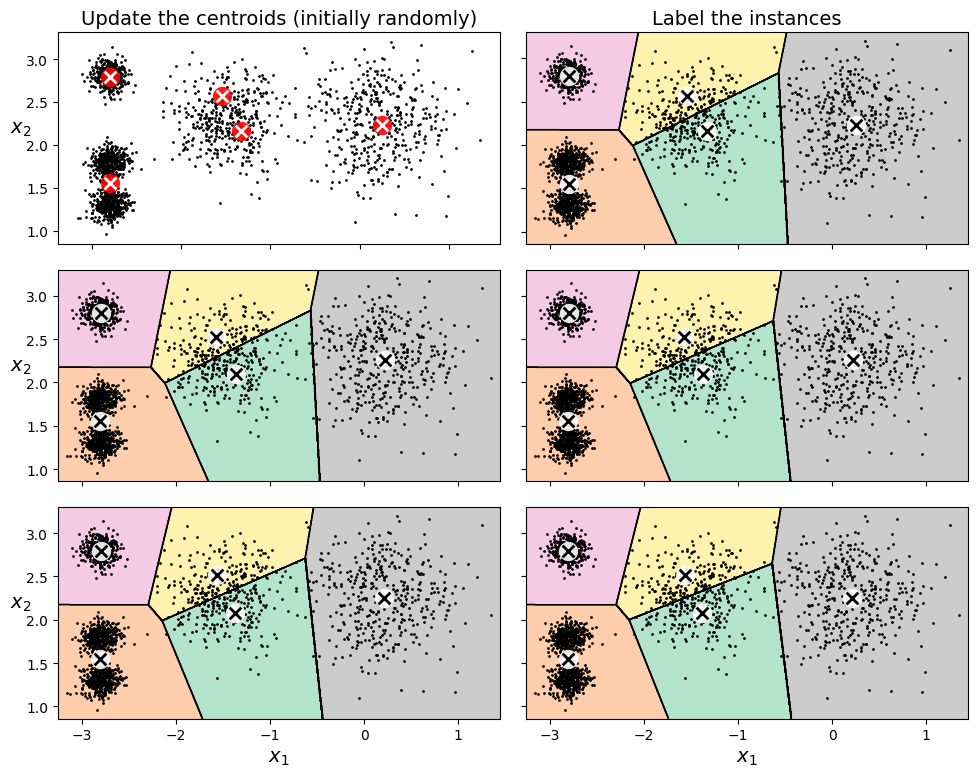

In [11]:
kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=1,
                      random_state=5)
kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=2,
                      random_state=5)
kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=3,
                      random_state=5)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)")

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False,
                         show_ylabels=False)
plt.title("Label the instances")

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False,
                         show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False,
                         show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

save_fig("kmeans_algorithm_plot")
plt.show()

**Centroid initialization methods**

NOTE:
- if centroid is known then init hyperparamter can be set to NumPy array containing the list of centroids  and n_init = 1
- n_init controls the number of random initialization , by def is equal to 10 that means whole algorithm runs 10 time after calling fit()  and sklearn keeps the model with the lowest intertia
- Model's inertia:
   - Sum of the squared distances between the instances and their closest centroids and used for finding the best solution
   - can be accessed via : inertia_
- score() method returns the negative intertia



In [12]:
kmeans.inertia_

224.07433122515735

In [13]:
kmeans.score(X)

-224.07433122515738

In [14]:
good_init = np.array([[--3, 3], [-3,2], [-3,1], [-1, 2], [0,2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.","array([[ 3, ... [ 0, 2]])"
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [15]:
good_init = np.array([[--3, 3], [-3,2], [-3,1], [-1, 2], [0,2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42, algorithm='elkan')
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.","array([[ 3, ... [ 0, 2]])"
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'elkan'


**Accelerated k-means and mini-batch k-means**

Note:
- algorithm='elkan' (be default 'lloyd') to use elkan's algorithm
- Min-batch algorithm = instead of using full datasets at each iteration, the algorithm is capable of using mini-batches, moving the centroids just slightly at each interation.
   - MiniBatchKMeans class from sklearn is used for this purpose
- much faster then regular k-means algorithm but worse at model's inertia generally

In [16]:
from sklearn.cluster import MiniBatchKMeans

mini = MiniBatchKMeans(n_clusters=5, random_state=42)
mini.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",42
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",'auto'


100/100

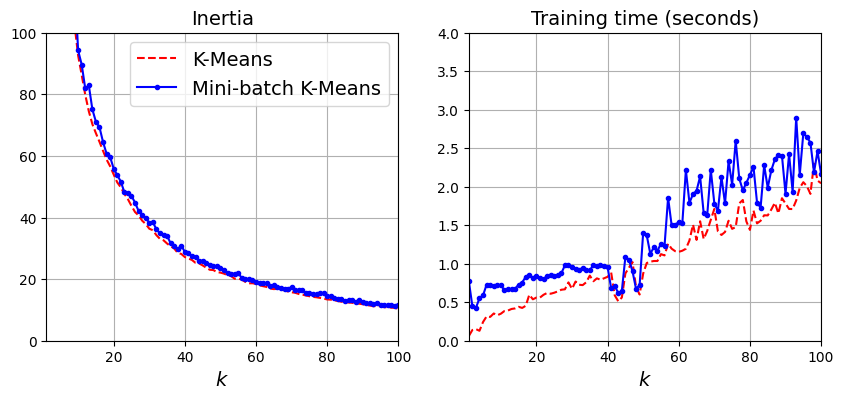

In [17]:
#ploting the inertia ratio and trainig time ratio between Minibatch K-means and regular K-means

from timeit import timeit

max_k = 100
times = np.empty((max_k, 2))
inertias = np.empty((max_k, 2))
for k in range(1, max_k + 1):
    kmeans_ = KMeans(n_clusters=k, algorithm="lloyd", n_init=10, random_state=42)
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42)
    print(f"\r{k}/{max_k}", end="")  # \r returns to the start of line
    times[k - 1, 0] = timeit("kmeans_.fit(X)", number=10, globals=globals())
    times[k - 1, 1] = timeit("minibatch_kmeans.fit(X)", number=10,
                             globals=globals())
    inertias[k - 1, 0] = kmeans_.inertia_
    inertias[k - 1, 1] = minibatch_kmeans.inertia_

plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.plot(range(1, max_k + 1), inertias[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), inertias[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$")
plt.title("Inertia")
plt.legend()
plt.axis([1, max_k, 0, 100])
plt.grid()

plt.subplot(122)
plt.plot(range(1, max_k + 1), times[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), times[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$")
plt.title("Training time (seconds)")
plt.axis([1, max_k, 0, 4])
plt.grid()

plt.show()

**Finding Optimal number of clusters**

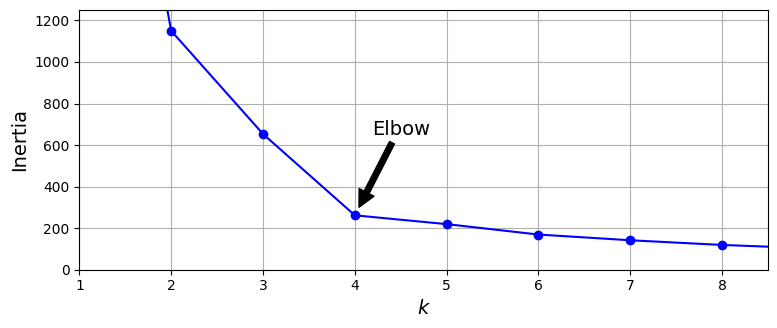

In [18]:
kmeans_per_k = [KMeans(n_clusters= k, n_init=10, random_state=42).fit(X)
                for k in range(1,10)]
inertias =  [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1,10), inertias, 'bo-')
plt.xlabel('$k$')
plt.ylabel('Inertia')
plt.annotate("", xy=(4, inertias[3]), xytext=(4.45, 650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(4.5, 650, "Elbow", horizontalalignment="center")
plt.axis([1, 8.5, 0, 1250])
plt.grid()
save_fig("inertia_as_a_function_of_number_of_clusters")
plt.show()

Silhouette score:
- mean of Silhouette coefficient over all the instances
- instance Silhouette coefficient = (b-a) / max(a,b) [ a = mean intra-cluster distance]
- more precise approach but computationally expensive
- varies between -1 to +1

In [19]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

0.629776248749872

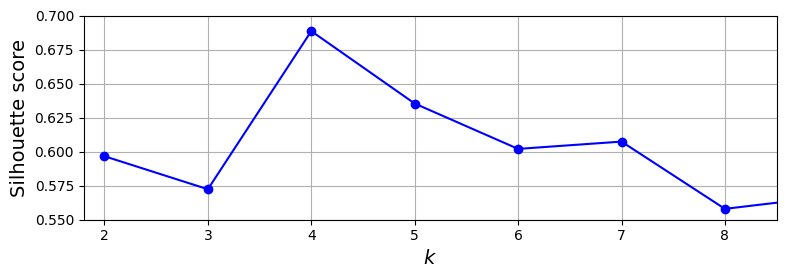

In [20]:
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
save_fig("silhouette_score_vs_k_plot")
plt.show()

- the above silhouette score based plot is far more clearer then the previous diagram
- here k=4 is a very good choice
- more informative visualization is obtained by silhouette diagram in which we plot every instance's silhouette coefficient sorted by the clusters they are assigned to and by the value of the coefficient
  - wider is better in the plot
  - hieght indicates number of instances

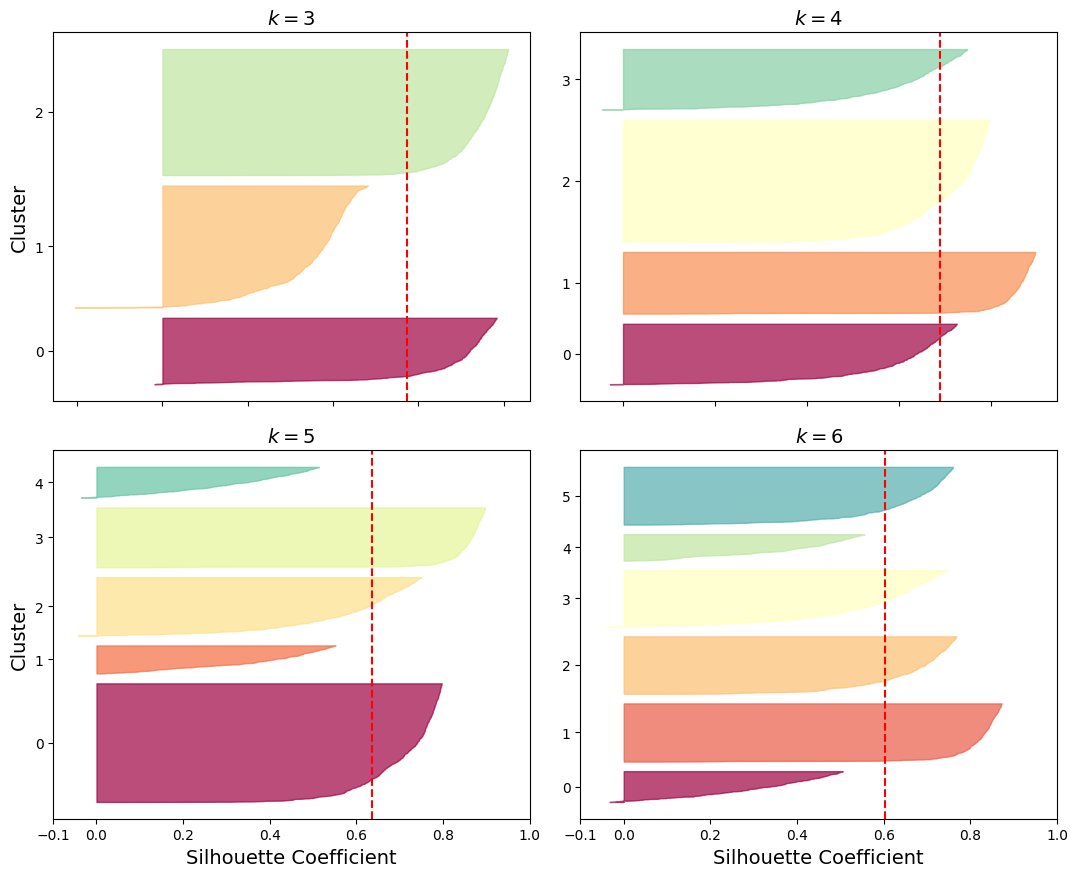

In [21]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)
    
    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")
    
    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$")

save_fig("silhouette_analysis_plot")
plt.show()

## Using Clustering for Image Segmentation

In [22]:
# extra code – downloads the ladybug image

import urllib.request

homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
filename = "ladybug.png"
filepath = IMAGES_PATH / filename
if not filepath.is_file():
    print("Downloading", filename)
    url = f"{homl3_root}/images/unsupervised_learning/{filename}"
    urllib.request.urlretrieve(url, filepath)

In [23]:
import PIL

image = np.asarray(PIL.Image.open(filepath))
image.shape

(533, 800, 3)

The shape is reperesented in 3d array using first dimension gives hieght , second gives width and the third gives the number of color channels (i.e. RGB in this case )


In [24]:
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters = 8, random_state=42).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

# outputs an image of the flower with 8 colors 

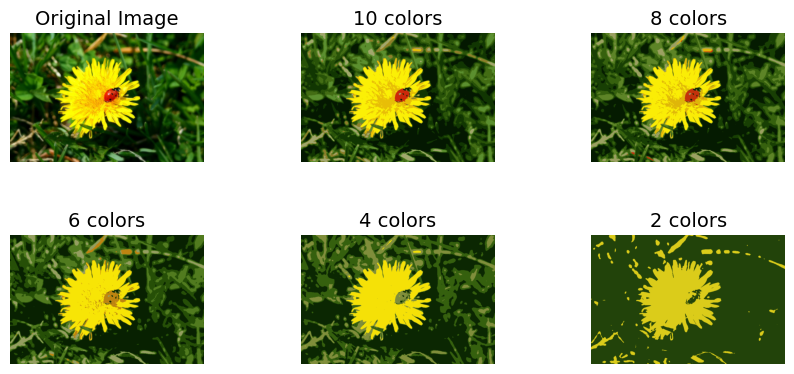

In [25]:
segmented_imgs = []
n_colors = (10, 8, 6, 4, 2)
for n_clusters in n_colors:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    segmented_imgs.append(segmented_img.reshape(image.shape))

plt.figure(figsize=(10, 5))
plt.subplots_adjust(wspace=0.5, hspace=0.1)

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')

for idx, n_clusters in enumerate(n_colors):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(segmented_imgs[idx] / 255)
    plt.title(f"{n_clusters} colors")
    plt.axis('off')

save_fig('image_segmentation.png', tight_layout = False)
plt.show()

In [26]:
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters = 10, random_state=42).fit(X)
seg_ig = kmeans.cluster_centers_[kmeans.labels_]
seg_ig = seg_ig.reshape(image.shape)

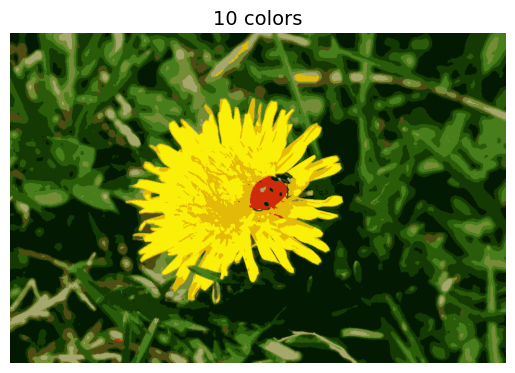

In [27]:
import matplotlib.pyplot as plt

plt.imshow(seg_ig.astype('uint8'))
plt.axis('off')
plt.title('10 colors')
plt.show()

**Using Clustering for Semi-Supervised Learning**

In [28]:
from sklearn.datasets import load_digits
X_digits, y_digits = load_digits(return_X_y = True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]


In [29]:
# for getting baseling performance we train the logistic regression model on 50 labeled instances (lets say):
from sklearn.linear_model import LogisticRegression
n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
#now checking the accuracy fo this model on the labeled test set :
log_reg.score(X_test, y_test)

0.7581863979848866

In [31]:
# representative image: image that is closest to the centroid
k = 50 
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

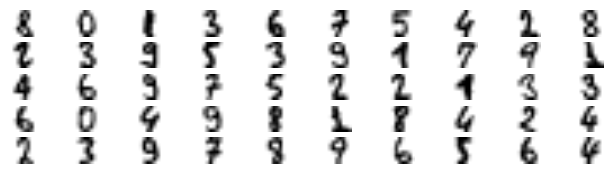

In [32]:
plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

save_fig("representative_images_plot", tight_layout=False)
plt.show()


In [33]:
#manually labeling the image
y_representative_digits = np.array([
8, 0, 1, 3, 6, 7, 5, 4, 1, 8, 2, 3, 9, 5, 3, 9, 1, 7, 9, 1, 4, 6, 9, 7, 5, 2, 2, 1, 3, 3, 6, 0, 4, 9, 8, 1, 8, 4, 2, 4, 2, 3, 9, 7, 8, 9, 6, 5, 6, 4
])


In [34]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.8387909319899244

Label Propogation: propogating the labels to all the other instances in the same cluster

In [35]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [36]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train, y_train_propagated)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
log_reg.score(X_test, y_test)

0.8337531486146096

In [38]:
percentile_closest = 99

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [39]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.836272040302267

In [40]:
(y_train_partially_propagated == y_train[partially_propagated]).mean()

np.float64(0.9340740740740741)

## DBSCAN

NOTE:
- Density-based spatial clustering of application with noise algorithm defines clusters as continuous regions of high density
  Working:
  - Each instance , algorithm counts how many instances are located within a small distance ε from it , called instances *ε-neighborhood*
  - core instances are thoes that are located in dense regions
  - all instances in nbd (neighborhood) of a core instance belong to the same cluster. it may include other core instance; therefore, a long sequence of neighboring core instances forms a single cluster
  - any instance that isn't a core instance and doesn't have one in its nbd is considered an anomaly
    

In [41]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.05
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


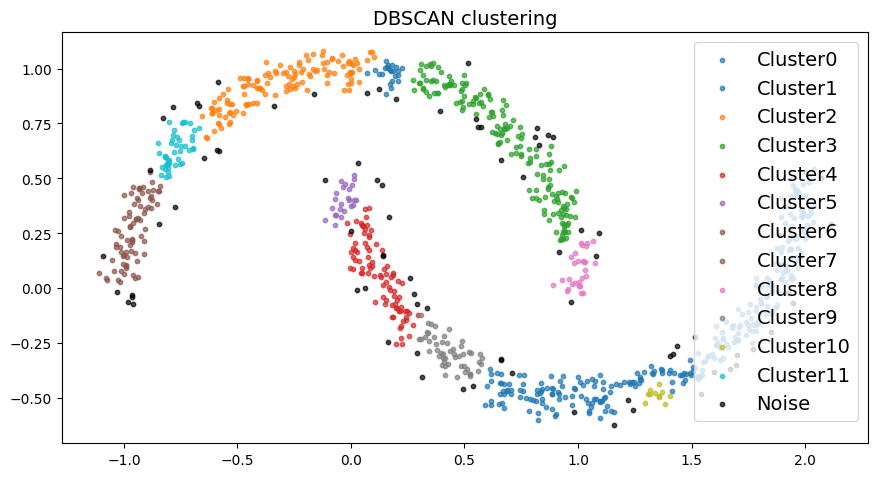

In [42]:
labels = dbscan.labels_
unique_labels = set(labels)

colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

fig, ax = plt.subplots(figsize=(9, 5))

for k, col in zip(unique_labels, colors):
    if k== -1:
        col = "black" # noise points


    mask = labels ==k
    ax.scatter(
        X[mask, 0], X[mask, 1], 
        c=[col], s=10, label=f"Noise" if k== -1 else f"Cluster{k}",
        alpha=0.7,
    )

ax.legend()
ax.set_title("DBSCAN clustering")
plt.tight_layout()
plt.show()


In [43]:
dbscan.labels_

array([ 9,  0, -1,  1,  1,  2,  3,  0,  0,  2,  3,  3, -1,  4,  5,  2,  0,
        2,  3,  0,  6,  7, -1,  0,  0,  7,  0,  0, -1,  0,  8, -1, -1,  2,
        3, -1,  9,  2,  3, -1,  0,  0,  3,  0,  0,  4,  3,  3,  2,  6,  2,
        0,  0,  0,  0,  6,  5,  3,  3,  0,  4,  9,  8,  3,  2,  2,  0,  5,
        0,  9, 10,  0, 10,  0,  0,  2,  2,  9,  0,  0, -1,  4, 11,  0,  0,
        3, 10,  3,  0,  4,  0,  3,  0,  0,  4,  6,  0,  0,  0,  9,  2,  3,
        2,  6,  0,  9,  0, 11,  2,  2,  2,  0,  3, -1,  0,  3,  3,  2,  0,
        6,  2,  3,  0,  5,  0,  3,  7,  4, -1,  3,  0,  4,  3,  0,  0, 10,
        0,  4,  6,  2,  9,  0,  2,  7, -1, -1, -1,  5, 11,  1,  9,  3,  0,
       -1,  0,  0,  9,  3,  8,  4, -1,  3,  0,  2,  6,  4,  2,  3,  0,  0,
        0,  9,  0,  9,  0,  9,  3,  3,  0,  0,  0, 11,  0, -1, -1,  4, -1,
        1, -1,  9,  0,  4,  1,  9,  5, 11,  0,  3,  0, -1, -1,  3, -1,  0,
        7,  0,  0,  2,  0,  2, -1,  7,  0,  1,  2,  0,  6,  0,  3,  2,  9,
        0,  3,  9,  3,  0

- cluster index that are -1 are considered anomalies by algorithm
- indices of core instances are available in the core_sample_indices_ instance variable
- 

In [44]:
dbscan.core_sample_indices_

array([  1,   3,   4,   5,   6,   7,   8,  10,  11,  13,  14,  15,  16,
        18,  19,  20,  23,  24,  25,  26,  27,  29,  30,  33,  34,  36,
        37,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  53,
        54,  55,  56,  57,  58,  59,  60,  61,  63,  64,  65,  66,  67,
        70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  81,  84,  85,
        86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
        99, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       114, 116, 117, 118, 119, 120, 121, 122, 124, 125, 126, 127, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       147, 148, 149, 150, 151, 155, 156, 157, 158, 159, 161, 162, 164,
       165, 166, 167, 168, 169, 170, 172, 173, 174, 175, 176, 177, 178,
       179, 180, 181, 182, 185, 187, 189, 190, 192, 193, 194, 195, 203,
       204, 205, 206, 207, 208, 209, 211, 212, 213, 214, 215, 216, 217,
       218, 220, 221, 222, 223, 224, 226, 227, 228, 229, 230, 23

In [45]:
dbscan.components_

array([[ 1.82829332, -0.0413549 ],
       [ 0.16468467,  1.00394314],
       [ 0.17576603,  0.91202019],
       ...,
       [-0.82102566,  0.54282832],
       [ 0.64220839, -0.38559947],
       [ 0.65861712, -0.43371153]], shape=(787, 2))

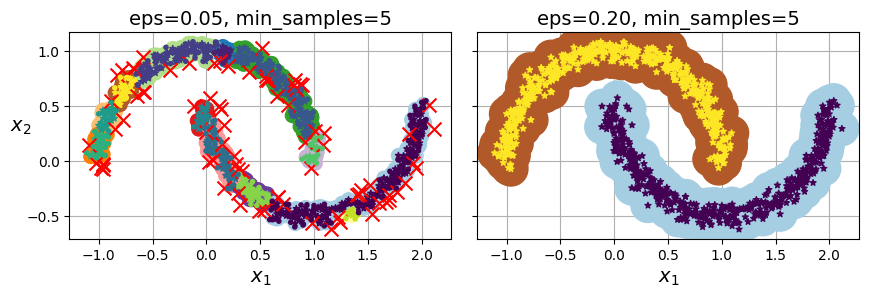

In [46]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]
    
    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

save_fig("DBSCAN clustering")
plt.show()


In [47]:
dbscan = dbscan2 # now we use eps = 0.2

In [48]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [49]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

In [50]:
knn.predict_proba(X_new)

array([[0.2 , 0.8 ],
       [1.  , 0.  ],
       [0.26, 0.74],
       [1.  , 0.  ]])

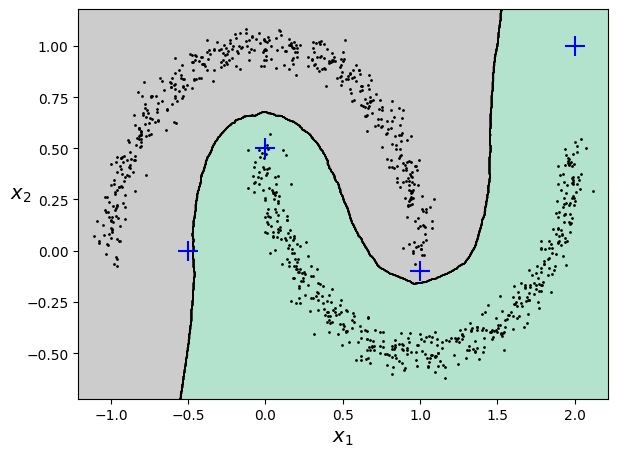

In [51]:
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
save_fig("cluster_classification_plot")
plt.show()

In [52]:
y_dist, y_pred_idx= knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  1, -1])

# Other Clustering Algorithms

Spectral Clustering

In [53]:
from sklearn.cluster import SpectralClustering

In [54]:
sc1 = SpectralClustering(n_clusters=2, gamma=100, random_state=42)
sc1.fit(X)

,"n_clusters n_clusters: int, default=8The dimension of the projection subspace.",2
,"eigen_solver eigen_solver: {'arpack', 'lobpcg', 'amg'}, default=NoneThe eigenvalue decomposition strategy to use. AMG requires pyamgto be installed. It can be faster on very large, sparse problems,but may also lead to instabilities. If None, then ``'arpack'`` isused. See [4]_ for more details regarding `'lobpcg'`.",None
,"n_components n_components: int, default=NoneNumber of eigenvectors to use for the spectral embedding. If None,defaults to `n_clusters`.",None
,"random_state random_state: int, RandomState instance, default=NoneA pseudo random number generator used for the initializationof the lobpcg eigenvectors decomposition when `eigen_solver =='amg'`, and for the K-Means initialization. Use an int to makethe results deterministic across calls (See:term:`Glossary `)... note:: When using `eigen_solver == 'amg'`, it is necessary to also fix the global numpy seed with `np.random.seed(int)` to get deterministic results. See https://github.com/pyamg/pyamg/issues/139 for further information.",42
,"n_init n_init: int, default=10Number of time the k-means algorithm will be run with differentcentroid seeds. The final results will be the best output of n_initconsecutive runs in terms of inertia. Only used if``assign_labels='kmeans'``.",10
,"gamma gamma: float, default=1.0Kernel coefficient for rbf, poly, sigmoid, laplacian and chi2 kernels.Ignored for ``affinity='nearest_neighbors'``, ``affinity='precomputed'``or ``affinity='precomputed_nearest_neighbors'``.",100
,"affinity affinity: str or callable, default='rbf'How to construct the affinity matrix. - 'nearest_neighbors': construct the affinity matrix by computing a graph of nearest neighbors. - 'rbf': construct the affinity matrix using a radial basis function (RBF) kernel. - 'precomputed': interpret ``X`` as a precomputed affinity matrix, where larger values indicate greater similarity between instances. - 'precomputed_nearest_neighbors': interpret ``X`` as a sparse graph of precomputed distances, and construct a binary affinity matrix from the ``n_neighbors`` nearest neighbors of each instance. - one of the kernels supported by :func:`~sklearn.metrics.pairwise.pairwise_kernels`.Only kernels that produce similarity scores (non-negative values thatincrease with similarity) should be used. This property is not checkedby the clustering algorithm.",'rbf'
,"n_neighbors n_neighbors: int, default=10Number of neighbors to use when constructing the affinity matrix usingthe nearest neighbors method. Ignored for ``affinity='rbf'``.",10
,"eigen_tol eigen_tol: float, default=""auto""Stopping criterion for eigen decomposition of the Laplacian matrix.If `eigen_tol=""auto""` then the passed tolerance will depend on the`eigen_solver`:- If `eigen_solver=""arpack""`, then `eigen_tol=0.0`;- If `eigen_solver=""lobpcg""` or `eigen_solver=""amg""`, then `eigen_tol=None` which configures the underlying `lobpcg` solver to automatically resolve the value according to their heuristics. See, :func:`scipy.sparse.linalg.lobpcg` for details.Note that when using `eigen_solver=""lobpcg""` or `eigen_solver=""amg""`values of `tol<1e-5` may lead to convergence issues and should beavoided... versionadded:: 1.2 Added 'auto' option.",'auto'
,"assign_labels assign_labels: {'kmeans', 'discretize', 'cluster_qr'}, default='kmeans'The strategy for assigning labels in the embedding space. There are twoways to assign labels after the Laplacian embedding. k-means is apopular choice, but it can be sensitive to initialization.Discretization is another approach which is less sensitive to randominitialization [3]_.The cluster_qr method [5]_ directly extract clusters from eigenvectorsin spectral clustering. In contrast to k-means and discretization, cluster_qrhas no tuning parameters and runs no iterations, yet may outperformk-means and discretization in terms of both quality and speed... versionchanged:: 1.1 Added new labeling method 'cluster_qr'

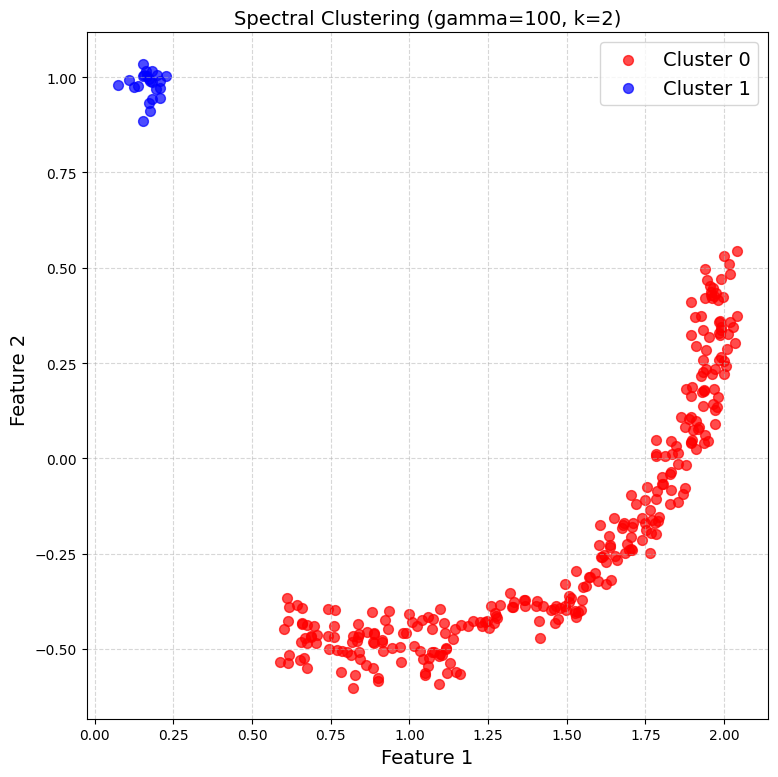

In [55]:
plt.figure(figsize=(8,8))
colors = ['red', 'blue'] # one color per cluster
for clusters in range(2):
        mask = labels== clusters
        plt.scatter(X[mask, 0], X[mask, 1], 
                c=colors[clusters], 
                label=f'Cluster {clusters}', 
                alpha=0.7, 
                s=50)
plt.title('Spectral Clustering (gamma=100, k=2)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2 ')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [56]:
sc1.affinity_matrix_.round(2)

array([[1.  , 0.  , 0.  , ..., 0.05, 0.  , 0.03],
       [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , ..., 0.  , 0.  , 0.  ],
       ...,
       [0.05, 0.  , 0.  , ..., 1.  , 0.  , 0.77],
       [0.  , 0.  , 0.  , ..., 0.  , 1.  , 0.  ],
       [0.03, 0.  , 0.  , ..., 0.77, 0.  , 1.  ]], shape=(1000, 1000))

In [57]:
sc2 = SpectralClustering(n_clusters = 3, gamma =50, random_state=42)
sc2.fit(X)

,"n_clusters n_clusters: int, default=8The dimension of the projection subspace.",3
,"eigen_solver eigen_solver: {'arpack', 'lobpcg', 'amg'}, default=NoneThe eigenvalue decomposition strategy to use. AMG requires pyamgto be installed. It can be faster on very large, sparse problems,but may also lead to instabilities. If None, then ``'arpack'`` isused. See [4]_ for more details regarding `'lobpcg'`.",None
,"n_components n_components: int, default=NoneNumber of eigenvectors to use for the spectral embedding. If None,defaults to `n_clusters`.",None
,"random_state random_state: int, RandomState instance, default=NoneA pseudo random number generator used for the initializationof the lobpcg eigenvectors decomposition when `eigen_solver =='amg'`, and for the K-Means initialization. Use an int to makethe results deterministic across calls (See:term:`Glossary `)... note:: When using `eigen_solver == 'amg'`, it is necessary to also fix the global numpy seed with `np.random.seed(int)` to get deterministic results. See https://github.com/pyamg/pyamg/issues/139 for further information.",42
,"n_init n_init: int, default=10Number of time the k-means algorithm will be run with differentcentroid seeds. The final results will be the best output of n_initconsecutive runs in terms of inertia. Only used if``assign_labels='kmeans'``.",10
,"gamma gamma: float, default=1.0Kernel coefficient for rbf, poly, sigmoid, laplacian and chi2 kernels.Ignored for ``affinity='nearest_neighbors'``, ``affinity='precomputed'``or ``affinity='precomputed_nearest_neighbors'``.",50
,"affinity affinity: str or callable, default='rbf'How to construct the affinity matrix. - 'nearest_neighbors': construct the affinity matrix by computing a graph of nearest neighbors. - 'rbf': construct the affinity matrix using a radial basis function (RBF) kernel. - 'precomputed': interpret ``X`` as a precomputed affinity matrix, where larger values indicate greater similarity between instances. - 'precomputed_nearest_neighbors': interpret ``X`` as a sparse graph of precomputed distances, and construct a binary affinity matrix from the ``n_neighbors`` nearest neighbors of each instance. - one of the kernels supported by :func:`~sklearn.metrics.pairwise.pairwise_kernels`.Only kernels that produce similarity scores (non-negative values thatincrease with similarity) should be used. This property is not checkedby the clustering algorithm.",'rbf'
,"n_neighbors n_neighbors: int, default=10Number of neighbors to use when constructing the affinity matrix usingthe nearest neighbors method. Ignored for ``affinity='rbf'``.",10
,"eigen_tol eigen_tol: float, default=""auto""Stopping criterion for eigen decomposition of the Laplacian matrix.If `eigen_tol=""auto""` then the passed tolerance will depend on the`eigen_solver`:- If `eigen_solver=""arpack""`, then `eigen_tol=0.0`;- If `eigen_solver=""lobpcg""` or `eigen_solver=""amg""`, then `eigen_tol=None` which configures the underlying `lobpcg` solver to automatically resolve the value according to their heuristics. See, :func:`scipy.sparse.linalg.lobpcg` for details.Note that when using `eigen_solver=""lobpcg""` or `eigen_solver=""amg""`values of `tol<1e-5` may lead to convergence issues and should beavoided... versionadded:: 1.2 Added 'auto' option.",'auto'
,"assign_labels assign_labels: {'kmeans', 'discretize', 'cluster_qr'}, default='kmeans'The strategy for assigning labels in the embedding space. There are twoways to assign labels after the Laplacian embedding. k-means is apopular choice, but it can be sensitive to initialization.Discretization is another approach which is less sensitive to randominitialization [3]_.The cluster_qr method [5]_ directly extract clusters from eigenvectorsin spectral clustering. In contrast to k-means and discretization, cluster_qrhas no tuning parameters and runs no iterations, yet may outperformk-means and discretization in terms of both quality and speed... versionchanged:: 1.1 Added new labeling method 'cluster_qr'.

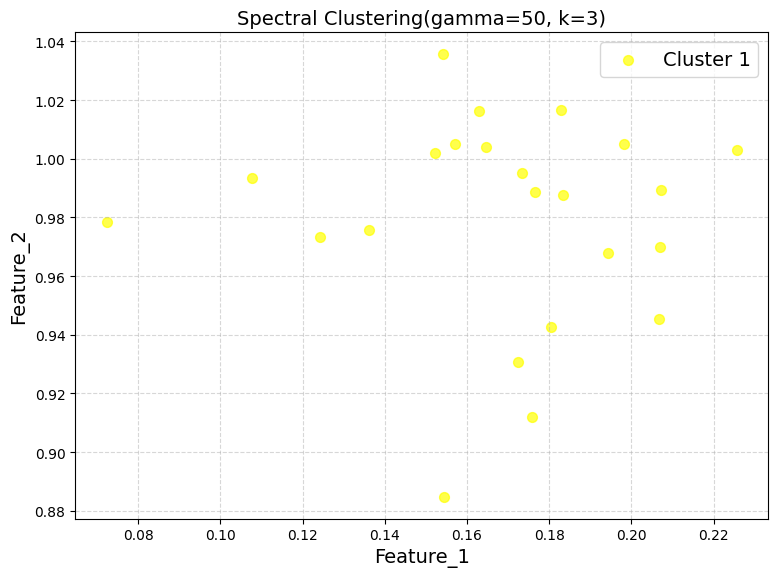

In [58]:
plt.figure(figsize=(8, 6))

colors = ['pink', 'yellow']

if clusters in range(3):
    mask = labels == clusters 
    plt.scatter(X[mask, 0], X[mask, 1],
                c= colors[clusters],
                label=f'Cluster {clusters}', 
                alpha=0.7, 
                s=50)
plt.title('Spectral Clustering(gamma=50, k=3)')
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.legend()
plt.grid(True, linestyle = '--', alpha=0.5)
plt.tight_layout()
plt.show()

    

In [59]:
def plot_spectral_clustering(sc, X, size, alpha, show_xlabels=True,
                             show_ylabels=True):
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=size, c='gray', alpha=alpha)
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=30, c='w')
    plt.scatter(X[:, 0], X[:, 1], marker='.', s=10, c=sc.labels_, cmap="Paired")
    
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"RBF gamma={sc.gamma}")
    

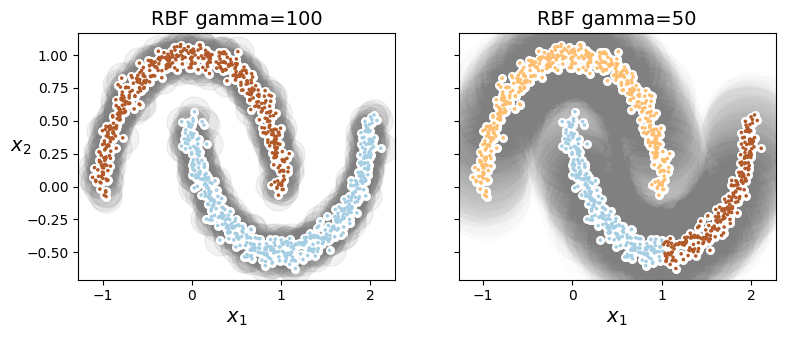

In [60]:
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_spectral_clustering(sc1, X, size=500, alpha=0.1)

plt.subplot(122)
plot_spectral_clustering(sc2, X, size=4000, alpha=0.01, show_ylabels=False)

plt.show()

**Agglomerative Clustering**

In [61]:
from sklearn.cluster import AgglomerativeClustering

In [62]:
X = np.array([0, 2, 4, 8, 10]).reshape(-1, 1)
agg = AgglomerativeClustering(linkage="complete").fit(X)

In [63]:
def learned_params(estimator):
    return [attrib for attrib in dir(estimator)
            if attrib.endswith('_') and not attrib.startswith('_')]

In [64]:
learned_params(agg)

['children_',
 'labels_',
 'n_clusters_',
 'n_connected_components_',
 'n_features_in_',
 'n_leaves_']

In [65]:
agg.children_

array([[0, 1],
       [3, 4],
       [2, 5],
       [6, 7]])

In [66]:
agg.labels_

array([0, 0, 0, 1, 1])

In [67]:
agg.n_clusters_

2

In [68]:
agg.n_connected_components_

1

In [69]:
agg.n_features_in_

1

In [70]:
agg.n_leaves_

5

## Gaussian Mixtures

In [71]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

In [72]:
from sklearn.mixture import GaussianMixture

In [73]:
gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",10
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [74]:
gm.weights_

array([0.40005972, 0.20961444, 0.39032584])

In [75]:
gm.means_

array([[-1.40764129,  1.42712848],
       [ 3.39947665,  1.05931088],
       [ 0.05145113,  0.07534576]])

In [76]:
gm.covariances_

array([[[ 0.63478217,  0.72970097],
        [ 0.72970097,  1.16094925]],

       [[ 1.14740131, -0.03271106],
        [-0.03271106,  0.95498333]],

       [[ 0.68825143,  0.79617956],
        [ 0.79617956,  1.21242183]]])

In [77]:
# checking whether or not the algorithm converged and how many iterations it took:
gm.converged_

True

In [78]:
gm.n_iter_

4

- Use predict() method for hard clustering (in hard clustering the model can easily assign each instance to the most likely cluster)
- use predict_proba() method for soft clustering( in soft clustering model estimates the probability that it belongs to a particular cluster )
- this this class reiles on the expectation - maximization algorithm (EM) which is similar to k-means but it's more of a generalized version of k-means that finds:
   - cluster centers
   - size
   - shape
   - oreintation

In [79]:
gm.predict(X)

array([2, 2, 0, ..., 1, 1, 1], shape=(1250,))

In [80]:
gm.predict_proba(X).round(3)

array([[0.   , 0.023, 0.977],
       [0.001, 0.016, 0.983],
       [1.   , 0.   , 0.   ],
       ...,
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ]], shape=(1250, 3))

- GMM (gaussian mixture model ) is a generative model means it can generate new , simliar data from the scratch 

In [81]:
X_new, y_new = gm.sample(6)
X_new.round(3)

array([[-2.325,  1.048],
       [-1.167,  1.628],
       [ 1.849,  2.074],
       [ 3.983,  1.499],
       [ 3.816,  0.53 ],
       [ 0.381, -0.562]])

In [82]:
y_new

array([0, 0, 1, 1, 1, 2])

In [83]:
y_new.dtype

dtype('int64')

In [84]:
X_new.dtype

dtype('float64')

- score_samples() method is used for finding the log of PDF (probability density function)
- we can also get the probability densities by finding the exponential of the score_samples()

In [85]:
L = gm.score_samples(X).round(3)

In [86]:
L

array([-2.608, -3.571, -3.33 , ..., -3.514, -4.398, -3.807], shape=(1250,))

In [87]:
import numpy as np 
exp_values = np.exp(L)

In [88]:
exp_values

array([0.07368176, 0.02812771, 0.03579311, ..., 0.02977757, 0.01230192,
       0.02221472], shape=(1250,))

Here exp_values are the values of the probability densities (which maybe any positive number instead of just being a value between 0 and 1)

EM (exepctation- maximization) algorithm can struggle to converge to optimal solution in case of high dimensions, clusters or few instances
to avoid this we impose constraints on the covariance matrices by using the **covariance_type** hyperparameter to one of following values:
- "spherical":
  - All clusters must be spherical
  - can have different diameters (i.e.  different variances)
- "diag":
   - take on any ellipsoidal shape of any size
   - axes of ellipse must be parallel to the coordinate axes (covariance matrices must be diagonal)
- "tied":
   - all ellipsoidal should have same shape, size, and orientation
   - all clusters share the same covariance matrix
-  by default = "full":
   - can take any shape, size and orientation
   - has its own unconstrained covariance matrix

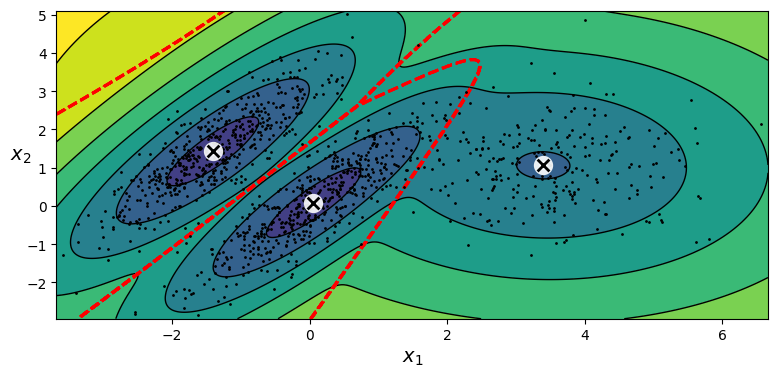

In [89]:
from matplotlib.colors import LogNorm

def plot_gaussian_mixture(clusterer, X, resolution=1000, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,
                linewidths=2, colors='r', linestyles='dashed')
    
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    plot_centroids(clusterer.means_, clusterer.weights_)

    plt.xlabel("$x_1$")
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)

save_fig("gaussian_mixtures_plot")
plt.show()

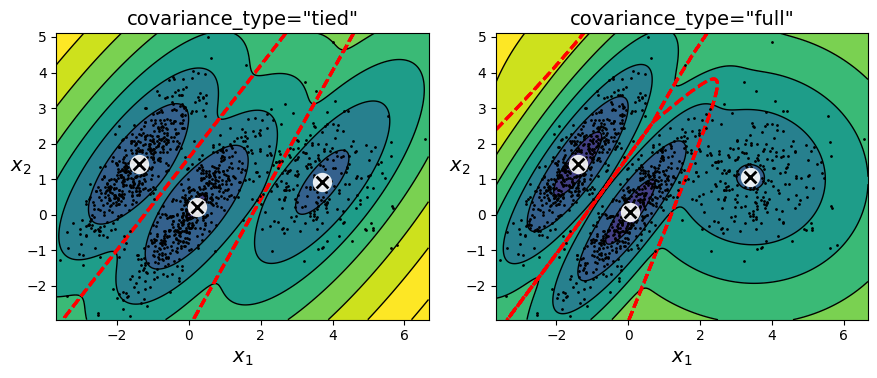

In [90]:
gm_full = GaussianMixture(n_components=3, n_init=10, covariance_type="full",
                          random_state=42)
gm_tied = GaussianMixture(n_components=3, n_init=10, covariance_type="tied",
                          random_state=42)
gm_spherical = GaussianMixture(n_components=3, n_init=10, covariance_type="spherical",
                               random_state=42)
gm_diag = GaussianMixture(n_components=3, n_init=10, covariance_type="diag",
                          random_state=42)
gm_full.fit(X)
gm_tied.fit(X)
gm_spherical.fit(X)
gm_diag.fit(X)

def compare_gaussian_mix(gm1, gm2, X):
    plt.figure(figsize=(9, 4))

    plt.subplot(121)
    plot_gaussian_mixture(gm1, X)
    plt.title(f'covariance_type="{gm1.covariance_type}"')

    plt.subplot(122)
    plot_gaussian_mixture(gm2, X)
    plt.title(f'covariance_type="{gm2.covariance_type}"')
compare_gaussian_mix(gm_tied, gm_full, X)
save_fig("covariance_type_plot")
plt.show()

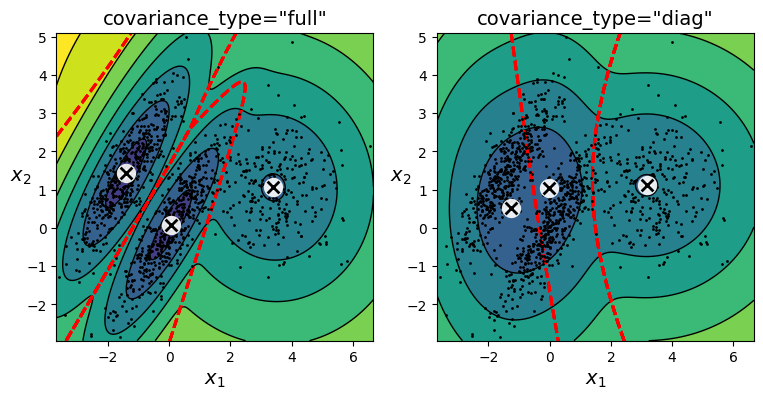

In [91]:
compare_gaussian_mix(gm_full, gm_diag, X)

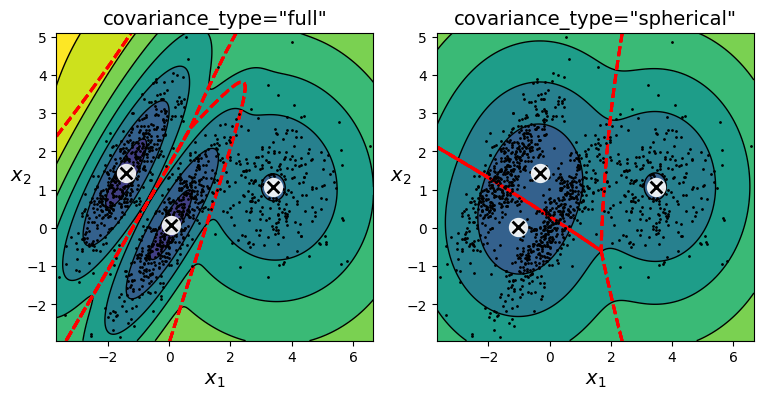

In [92]:
compare_gaussian_mix(gm_full, gm_spherical, X)

**Using Gaussian Mixtures for Anomaly Detection**

For anomaly detection:
- Set a density threshold
- If:
   - density threshold give too many false negatives then increase the threshold
   - if it gives too many false positives then reduce the threshold 

In [93]:
den = gm.score_samples(X)
den_thresh = np.percentile(den, 2 )
anomalies = X[den < den_thresh]

In [94]:
anomalies.round(2)

array([[ 0.74, -1.  ],
       [-2.54, -2.77],
       [-1.75, -0.78],
       [ 0.54,  5.  ],
       [-0.51, -2.16],
       [-1.8 , -0.97],
       [-3.39, -2.28],
       [ 1.58,  4.2 ],
       [-2.06,  2.27],
       [-2.54, -2.83],
       [-1.93, -1.19],
       [-0.27, -1.87],
       [-1.93,  2.49],
       [ 5.81, -0.85],
       [ 5.68,  0.21],
       [ 3.55,  3.48],
       [ 5.55,  2.77],
       [ 4.01,  4.87],
       [ 3.23,  3.73],
       [ 5.61,  2.05],
       [ 5.62, -0.94],
       [ 2.31, -1.02],
       [ 6.57,  2.13],
       [ 3.22, -1.29],
       [ 4.08,  3.2 ]])

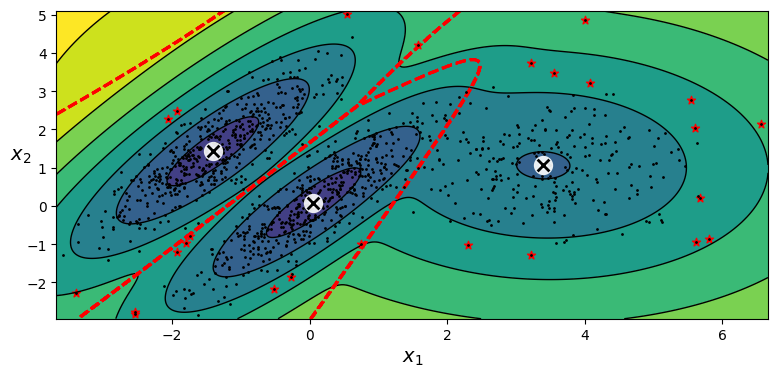

In [95]:
plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)
plt.scatter(anomalies[:,0], anomalies[:, 1], color='r', marker='*')
plt.ylim(top=5.1)
save_fig("anomaly detection using a guassian mixture model")
plt.show()

**Selecting the number of Clusters**

Try to find model that minimizes a theoretical information criterian, such as BIC( Bayesian information criterian) or AIC(akaike information criteria):
- bic() for BIC
- aic() for AIC 

In [97]:
gm.bic(X)

8189.733705221636

In [98]:
gm.aic(X)

8102.508425106598

Calculating BIC manually:

In [101]:
n_clusters = 3
n_dims = 3
n_params_for_weights = n_clusters - 1
n_params_for_means = n_clusters * n_dims
n_params_for_covariance = n_clusters * n_dims *(n_dims + 1)// 2 
n_params = n_params_for_weights + n_params_for_means + n_params_for_covariance
max_log_likelihood = gm.score(X) * len(X) # log(l^)
bic = np.log(len(X)) * n_params - 2 *max_log_likelihood
aic = 2 * n_params - 2 * max_log_likelihood
print(f"bic = {bic}")
print(f"aic = {aic}")
print(f"n_params = {n_params}")

bic = 8275.304491185192
aic = 8126.508425106598
n_params = 29


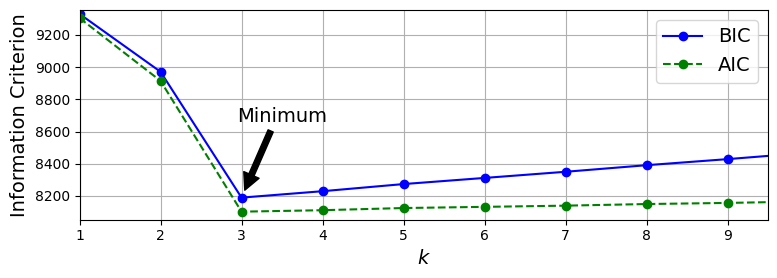

In [102]:
gms_per_k = [GaussianMixture(n_components=k , n_init= 10, random_state=42).fit(X)
             for k in range(1,11)]
bics = [model.bic(X) for model in gms_per_k ]
aics = [model.aic(X) for model in gms_per_k ] 

plt.figure(figsize = (8, 3))
plt.plot(range(1,11), bics, "bo-", label="BIC")
plt.plot(range(1,11), aics, "go--", label="AIC")
plt.xlabel("$k$")
plt.ylabel("Information Criterion")
plt.axis([1, 9.5, min(aics) - 50 , max(aics) + 50])
plt.annotate("", xy=(3, bics[2]), xytext= (3.4, 8650),
             arrowprops = dict(facecolor='black', shrink=0.1))
plt.text(3.5, 8660, "Minimum", horizontalalignment="center")
plt.legend()
plt.grid()
save_fig("aic_bic_vs_k_plot")
plt.show()

## Bayesian Gaussian Mixture Model

In [109]:
from sklearn.mixture import BayesianGaussianMixture
bgm = BayesianGaussianMixture(n_components=10, n_init=5, random_state=42)
bgm.fit(X)
bgm.weights_.round(2)

C:\Users\ankur\AppData\Roaming\Python\Python314\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


array([0.4 , 0.21, 0.  , 0.4 , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

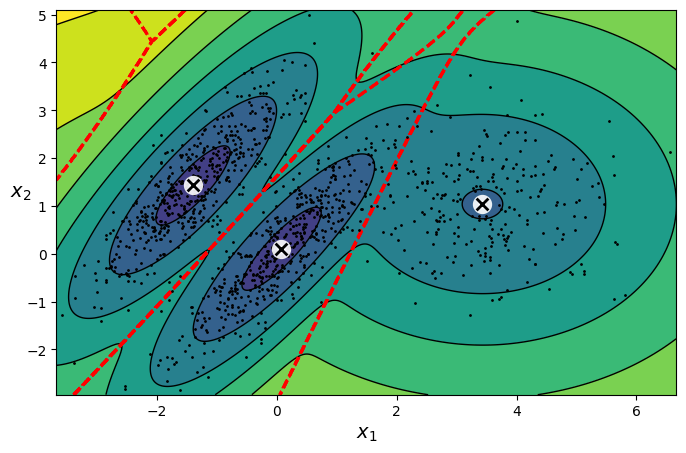

In [110]:
plt.figure(figsize=(8,5))
plot_gaussian_mixture(bgm, X)
plt.show()

C:\Users\ankur\AppData\Roaming\Python\Python314\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


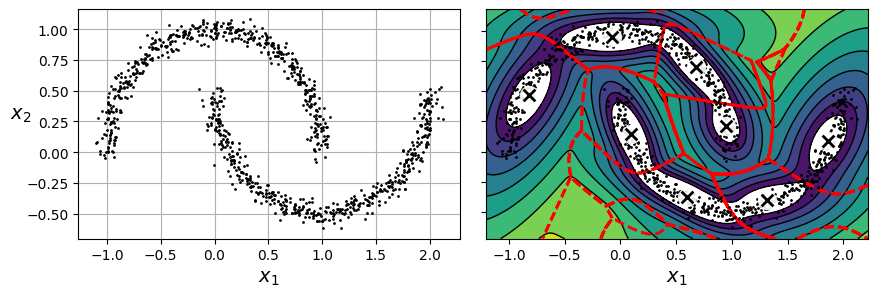

In [114]:
# practising the same on moons datasets 
from sklearn.datasets import make_moons
X_moons , y_moons = make_moons(n_samples = 1000, noise = 0.05, random_state=42)

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X_moons)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_data(X_moons)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.grid()

plt.subplot(122)
plot_gaussian_mixture(bgm, X_moons, show_ylabels=False)

save_fig("moons_vs_bgm_plot")
plt.show()


Chapter ends :)  here the exercises will be shared in another notebook !